In [1]:
HYPERPARAM_ITERS = 50  # Number of iterations for hyperparameter tuning
EXPORT = True  # Whether to export the trained models; set to True to save the models to disk.

# Data Preprocessing

While we did a lot of data cleaning and preprocessing in other notebooks (see notebooks in [data directory](./data)), we will load the data here and do some additional preprocessing to prepare it for model training. This includes combining flight and weather data, adding some historical and derived columns, as well as encoding categorical variables and splitting the data into training and testing sets.

In [2]:
import polars as pl

# Load the data
df = pl.read_parquet("data/flights/Full_Flight_Data.parquet")
df = df.sort("FL_DATE")
df.shape, df.head(), df.tail()

((480802, 60),
 shape: (5, 60)
 ┌─────────────┬─────────────┬────────────┬────────────┬───┬───────┬────────────┬────────────┬──────┐
 │ FL_DATE     ┆ MKT_UNIQUE_ ┆ MKT_CARRIE ┆ OP_UNIQUE_ ┆ … ┆ SPEED ┆ TC-DATA-SH ┆ TC-DATA-HO ┆      │
 │ ---         ┆ CARRIER     ┆ R_FL_NUM   ┆ CARRIER    ┆   ┆ ---   ┆ EET        ┆ LDER       ┆ ---  │
 │ datetime[μs ┆ ---         ┆ ---        ┆ ---        ┆   ┆ str   ┆ ---        ┆ ---        ┆ str  │
 │ ]           ┆ str         ┆ i64        ┆ str        ┆   ┆       ┆ str        ┆ str        ┆      │
 ╞═════════════╪═════════════╪════════════╪════════════╪═══╪═══════╪════════════╪════════════╪══════╡
 │ 2024-01-01  ┆ AA          ┆ 1064       ┆ AA         ┆ … ┆ 0000  ┆ A28NM      ┆ AIRBUS SAS ┆ null │
 │ 00:00:00    ┆             ┆            ┆            ┆   ┆       ┆            ┆ …          ┆      │
 │ 2024-01-01  ┆ AA          ┆ 1153       ┆ AA         ┆ … ┆ 0000  ┆            ┆ …          ┆ null │
 │ 00:00:00    ┆             ┆            ┆        

In [3]:
# Bring in weather data
weather_df = pl.read_parquet("data/weather/isd_weather_data.parquet").sort("timestamp")

# Calculate the actual scheduled departure timestamp from the flight date and scheduled departure time. This keeps the weather alignment consistent with weather info that would have been available at the time of the scheduled departure
df = df.with_columns(
    (
        pl.col("FL_DATE")
        + pl.duration(
            hours=(pl.col("CRS_DEP_TIME") // 100).cast(pl.Int64),
            minutes=(pl.col("CRS_DEP_TIME") % 100).cast(pl.Int64),
        )
    ).alias("scheduled_departure_ts")
).sort("scheduled_departure_ts")

# Merge in most recent weather data that would have been known by scheduled departure
df = df.join_asof(
    weather_df,
    left_on="scheduled_departure_ts",
    right_on="timestamp",
    strategy="backward",
    tolerance="3h",
).drop("timestamp")
df.shape, df.tail(), df.get_column("scheduled_departure_ts")

((480802, 73),
 shape: (5, 73)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ FL_DATE   ┆ MKT_UNIQU ┆ MKT_CARRI ┆ OP_UNIQUE ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_ │
 │ ---       ┆ E_CARRIER ┆ ER_FL_NUM ┆ _CARRIER  ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ height_m │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ μs]       ┆ str       ┆ i64       ┆ str       ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 2025-08-2 ┆ AA        ┆ 4643      ┆ YX        ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
 │ 7         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 00:00:00  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 2025-08-2 ┆ AA        ┆ 5613      ┆ OH        ┆ 

In [4]:
from holidays import US

# Time-of-day feature column names
TOD_MONTH = "month"
TOD_DOW = "day_of_week"
TOD_DOM = "day_of_month"
TOD_WEEKEND = "is_weekend"
TOD_HOLIDAY = "is_holiday"

# All derived from scheduled_departure_ts (FL_DATE + CRS_DEP_TIME);
df = df.with_columns(
    [
        pl.col("scheduled_departure_ts").dt.weekday().alias(TOD_DOW),  # 0=Mon, 6=Sun
        pl.col("scheduled_departure_ts").dt.month().cast(pl.Int8).alias(TOD_MONTH),
        pl.col("scheduled_departure_ts").dt.day().cast(pl.Int8).alias(TOD_DOM),
        (pl.col("scheduled_departure_ts").dt.weekday() >= 5)
        .cast(pl.Int8)
        .alias(TOD_WEEKEND),
        (
            pl.col("scheduled_departure_ts")
            .dt.date()
            .map_elements(lambda x: x in US())  # ty:ignore[unresolved-attribute]
            .cast(pl.Int8)
        ).alias(TOD_HOLIDAY),
    ]
)
df.select([TOD_DOW, TOD_MONTH, TOD_WEEKEND, TOD_HOLIDAY]).head()

day_of_week,month,is_weekend,is_holiday
i8,i8,i8,i8
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1


In [5]:
df = df.with_columns(
    pl.col(
        "MODEL"
    ).str.strip_chars()  # Remove leading/trailing whitespace from MODEL column (e.g., "737-800 " -> "737-800"
)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,MFR MDL CODE,ENG MFR MDL,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday
datetime[μs],str,i64,str,i64,str,i64,i64,i64,str,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,…,str,str,i32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,datetime[μs],f64,f64,f64,f64,f64,str,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8
2024-01-01 00:00:00,"""AA""",489,"""AA""",19805,"""N433AN""",489,14107,30466,"""PHX""",11278,51,47,-4.0,-1,13.0,100,630,5.0,700,635,-25.0,0.0,null,0.0,249.0,228.0,210.0,1.0,1979.0,null,null,null,null,null,null,0,…,"""3940051""","""13115""",2021,"""433AN""","""3940051""","""3940051""","""AIRBUS ""","""A321-253NX""","""5""","""5 ""","""1""","""0""","""02""","""222""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,2024-01-01 00:51:00,7.2,-0.6,1016.3,160.0,3.1,"""7-8_oktas""",null,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,"""13844CB""","""13804""",2012,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",5414,"""OH""",20397,"""N526EA""",5414,11423,31423,"""DSM""",11278,500,449,-11.0,-1,60.0,549,844,4.0,832,848,16.0,0.0,null,0.0,152.0,179.0,115.0,1.0,897.0,0.0,0.0,16.0,0.0,0.0,null,0,…,"""1390015""","""30052""",2010,"""526EA""","""1390015""","""1390015""","""BOMBARDIER INC ""","""CL-600-2C10""","""5""","""5 ""","""1""","""0""","""02""","""080""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,"""13844FZ""","""13134""",2018,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",5330,"""OH""",20397,"""N529EA""",5330,10581,30581,"""BGR""",11278,514,504,-10.0,-1,20.0,524,655,11.0,740,706,-34.0,0.0,null,0.0,146.0,122.0,91.0,1.0,590.0,null,null,null,null,null,null,0,…,"""1390015""","""30052""",2010,"""529EA""","""1390015""","""1390015""","""BOMBARDIER INC ""","""CL-600-2C10""","""5""","""5 ""","""1""","""0""","""02""","""080""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 05:14:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1


### Add rolling 7-day average delays and cancellations for destination airports

In [6]:
df = df.sort(["DEST_AIRPORT_ID", "scheduled_departure_ts"])

# 7 Day rolling average delay for destination airport
rolling_avg = (
    df.group_by_dynamic(
        index_column="scheduled_departure_ts",
        every="1d",
        period="7d",
        group_by="DEST_AIRPORT_ID",
        closed="left",
    )
    .agg(pl.col("DEP_DELAY").mean().alias("avg_delay_dest_7d"))
    .sort(["DEST_AIRPORT_ID", "scheduled_departure_ts"])
)

# 7 Day rolling cancellation rate by destination airport
rolling_cancel_rate = df.group_by_dynamic(
    index_column="scheduled_departure_ts",
    every="1d",
    period="7d",
    group_by="DEST_AIRPORT_ID",
    closed="left",
).agg(pl.col("CANCELLED").mean().alias("cancel_rate_dest_7d"))

df = df.join_asof(
    rolling_avg, on="scheduled_departure_ts", by="DEST_AIRPORT_ID", strategy="backward"
)

df = df.join_asof(
    rolling_cancel_rate,
    on="scheduled_departure_ts",
    by="DEST_AIRPORT_ID",
    strategy="backward",
)

df.sort("cancel_rate_dest_7d", descending=True).select(
    ["DEST_AIRPORT_ID", "scheduled_departure_ts", "cancel_rate_dest_7d"]
).head(10)

/var/folders/l4/p__14z5x5rl4rjxvfwyqm1z00000gn/T/ipykernel_95280/46150899.py:25: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df = df.join_asof(
/var/folders/l4/p__14z5x5rl4rjxvfwyqm1z00000gn/T/ipykernel_95280/46150899.py:29: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df = df.join_asof(


DEST_AIRPORT_ID,scheduled_departure_ts,cancel_rate_dest_7d
i64,datetime[μs],f64
14986,2024-10-08 08:32:00,1.0
14986,2024-10-09 08:32:00,1.0
14986,2024-10-07 08:32:00,0.857143
14986,2024-10-10 08:32:00,0.857143
10980,2025-06-25 19:45:00,0.833333
10980,2025-06-26 19:45:00,0.833333
10208,2024-09-27 20:59:00,0.727273
10208,2024-09-27 20:59:00,0.727273
10208,2025-06-25 19:50:00,0.714286


In [7]:
df = df.with_columns(
    pl.col(pl.Utf8).cast(pl.Categorical),
    pl.col("scheduled_departure_ts").dt.epoch(
        time_unit="s"
    ),  # Convert datetime to epoch seconds
)

# Drop cancelled flights, and then drop any rows with null values
df = df.filter(pl.col("CANCELLED") == 0)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday,avg_delay_dest_7d,cancel_rate_dest_7d
datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,i64,…,i32,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8,f64,f64
2024-05-15 00:00:00,"""B6""",2494,"""B6""",20409,"""N328JB""",2494,11278,30852,"""DCA""",10154,1559,1616,17.0,1,13.0,1629,1730,5.0,1731,1735,4.0,0.0,null,0.0,92.0,79.0,61.0,1.0,405.0,null,null,null,null,null,null,0,…,2011,"""328JB""","""3260408""","""3260408""","""EMBRAER ""","""ERJ 190-100 IGW""","""5""","""5 ""","""1""","""0""","""02""","""020""","""CLASS 2""","""0000""","""A57NM ""","""YABORA INDUSTRIA AERONAUTICA S…",null,1715788740,17.8,15.6,1007.4,20.0,5.1,"""10_oktas_overcast""",3.0,null,0,0,16000,null,3,5,15,0,0,4.0,0.0
2024-05-16 00:00:00,"""B6""",2494,"""B6""",20409,"""N324JB""",2494,11278,30852,"""DCA""",10154,1559,1551,-8.0,-1,17.0,1608,1713,5.0,1731,1718,-13.0,0.0,null,0.0,92.0,87.0,65.0,1.0,405.0,null,null,null,null,null,null,0,…,2010,"""324JB""","""3260408""","""3260408""","""EMBRAER ""","""ERJ 190-100 IGW""","""5""","""5 ""","""1""","""0""","""02""","""020""","""CLASS 2""","""0000""","""A57NM ""","""YABORA INDUSTRIA AERONAUTICA S…",null,1715875140,23.9,13.9,1007.2,350.0,7.2,"""2-3_oktas""",0.0,null,0,0,16000,null,4,5,16,0,0,0.857143,0.0
2024-05-17 00:00:00,"""B6""",2494,"""B6""",20409,"""N334JB""",2494,11278,30852,"""DCA""",10154,1559,1614,15.0,1,18.0,1632,1732,5.0,1731,1737,6.0,0.0,null,0.0,92.0,83.0,60.0,1.0,405.0,null,null,null,null,null,null,0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1715961540,20.0,14.4,1014.8,60.0,2.6,"""10_oktas_overcast""",0.0,null,0,0,16000,null,5,5,17,1,0,2.333333,0.142857
2024-05-18 00:00:00,"""B6""",2494,"""B6""",20409,"""N355JB""",2494,11278,30852,"""DCA""",10154,1559,1641,42.0,2,38.0,1719,1818,12.0,1731,1830,59.0,0.0,null,0.0,92.0,109.0,59.0,1.0,405.0,42.0,0.0,17.0,0.0,0.0,"""1544""",0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1716047940,17.2,15.0,1014.9,130.0,2.6,"""10_oktas_overcast""",0.0,null,0,0,16000,null,6,5,18,1,0,-1.333333,0.142857
2024-05-19 00:00:00,"""B6""",2494,"""B6""",20409,"""N329JB""",2494,11278,30852,"""DCA""",10154,1559,1547,-12.0,-1,16.0,1603,1705,6.0,1731,1711,-20.0,0.0,null,0.0,92.0,84.0,62.0,1.0,405.0,null,null,null,null,null,null,0,…,2011,"""329JB""","""3260408""","""3260408""","""EMBRAER ""","""ERJ 190-100 IGW""","""5""","""5 ""","""1""","""0""","""02""","""020""","""CLASS 2""","""0000""","""A57NM ""","""YABORA INDUSTRIA AERONAUTICA S…",null,1716134340,20.0,15.6,1016.2,60.0,1.5,"""10_oktas_overcast""",0.0,null,0,0,14000,null,7,5,19,1,0,-9.833333,0.142857


Route average delay

In [8]:
df = df.sort("scheduled_departure_ts").with_row_index("_idx")

# Route average delay
df = df.with_columns(
    [
        pl.concat_str(
            pl.col("ORIGIN"), pl.lit("→"), pl.col("DEST_AIRPORT_ID").cast(pl.Utf8)
        ).alias("route"),
        pl.col("DEP_DELAY").cast(pl.Float64).alias("_dep_delay"),
        pl.col("CANCELLED").cast(pl.Float64).alias("_cancelled"),
    ]
)

df = df.with_columns(pl.col("_dep_delay").mean().over("route").alias("avg_rte_delay"))

df = df.with_columns(
    pl.col("_cancelled").mean().over("route").alias("avg_rte_cancelled")
).drop(["_dep_delay", "_cancelled"])

df.head()

_idx,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,…,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday,avg_delay_dest_7d,cancel_rate_dest_7d,route,avg_rte_delay,avg_rte_cancelled
u32,datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,…,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8,f64,f64,str,f64,f64
0,2024-01-01 00:00:00,"""AA""",489,"""AA""",19805,"""N433AN""",489,14107,30466,"""PHX""",11278,51,47,-4.0,-1,13.0,100,630,5.0,700,635,-25.0,0.0,null,0.0,249.0,228.0,210.0,1.0,1979.0,null,null,null,null,null,null,…,"""3940051""","""AIRBUS ""","""A321-253NX""","""5""","""5 ""","""1""","""0""","""02""","""222""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704070260,7.2,-0.6,1016.3,160.0,3.1,"""7-8_oktas""",null,null,0,0,16000,null,1,1,1,0,1,7.402881,0.008752,"""PHX→11278""",5.849414,0.0
1,2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,…,"""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,11.673913,0.0,"""DCA→11057""",18.405263,0.0
2,2024-01-01 00:00:00,"""AA""",5414,"""OH""",20397,"""N526EA""",5414,11423,31423,"""DSM""",11278,500,449,-11.0,-1,60.0,549,844,4.0,832,848,16.0,0.0,null,0.0,152.0,179.0,115.0,1.0,897.0,0.0,0.0,16.0,0.0,0.0,null,…,"""1390015""","""BOMBARDIER INC ""","""CL-600-2C10""","""5""","""5 ""","""1""","""0""","""02""","""080""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,7.402881,0.008752,"""DSM→11278""",13.510277,0.0
3,2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,…,"""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,6.064935,0.0,"""DCA→13303""",16.936007,0.0
4,2024-01-01 00:00:00,"""AA""",5330,"""OH""",20397,"""N529EA""",5330,10581,30581,"""BGR""",11278,514,504,-10.0,-1,20.0,524,655,11.0,740,706,-34.0,0.0,null,0.0,146.0,122.0,91.0,1.0,590.0,null,null,null,null,null,null,…,"""1390015""","""BOMBARDIER INC ""","""CL-600-2C10""","""5""","""5 ""","""1""","""0""","""02""","""080""","""CLASS 3""","""0000""",""" """,""" …",null,1704086040,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,7.402881,0.008752,"""BGR→11278""",18.975578,0.0


Drop flights not departing from DCA


In [9]:
# Drop non-DCA originating flights
df = df.filter(pl.col("ORIGIN_AIRPORT_ID") == 11278)
df.shape, df.columns

((233124, 84),
 ['_idx',
  'FL_DATE',
  'MKT_UNIQUE_CARRIER',
  'MKT_CARRIER_FL_NUM',
  'OP_UNIQUE_CARRIER',
  'OP_CARRIER_AIRLINE_ID',
  'TAIL_NUM',
  'OP_CARRIER_FL_NUM',
  'ORIGIN_AIRPORT_ID',
  'ORIGIN_CITY_MARKET_ID',
  'ORIGIN',
  'DEST_AIRPORT_ID',
  'CRS_DEP_TIME',
  'DEP_TIME',
  'DEP_DELAY',
  'DEP_DELAY_GROUP',
  'TAXI_OUT',
  'WHEELS_OFF',
  'WHEELS_ON',
  'TAXI_IN',
  'CRS_ARR_TIME',
  'ARR_TIME',
  'ARR_DELAY',
  'CANCELLED',
  'CANCELLATION_CODE',
  'DIVERTED',
  'CRS_ELAPSED_TIME',
  'ACTUAL_ELAPSED_TIME',
  'AIR_TIME',
  'FLIGHTS',
  'DISTANCE',
  'CARRIER_DELAY',
  'WEATHER_DELAY',
  'NAS_DELAY',
  'SECURITY_DELAY',
  'LATE_AIRCRAFT_DELAY',
  'FIRST_DEP_TIME',
  'DIV_AIRPORT_LANDINGS',
  'DIV_REACHED_DEST',
  'DIV_ACTUAL_ELAPSED_TIME',
  'N-NUMBER',
  'SERIAL NUMBER',
  'MFR MDL CODE',
  'ENG MFR MDL',
  'YEAR MFR',
  'N_NUMBER_CLEAN',
  'MFR_CODE_CLEAN',
  'CODE',
  'MFR',
  'MODEL',
  'TYPE-ACFT',
  'TYPE-ENG',
  'AC-CAT',
  'BUILD-CERT-IND',
  'NO-ENG',
  'NO-SEATS

Distance - not including because it does not seem to improve model performance right now.

In [10]:
# import math as _math

# # --- Distance feature column names ---
# DIST_LOG     = "dist_log"
# DIST_BUCKET  = "dist_bucket"
# DIST_WEATHER = "dist_x_weather_severity"

# # weather_severity: composite 0–1 index averaged across three indicators (higher = worse)
# _weather_severity = (
#     (pl.col("windspeed").fill_null(0) / 150.0).clip(0.0, 1.0)
#     + (1.0 - (pl.col("visibility_m").fill_null(16000) / 16000.0).clip(0.0, 1.0))
#     + (pl.col("precipitation-1h").fill_null(0) > 0).cast(pl.Float64)
# ) / 3.0

# df = df.with_columns([
#     pl.col("DISTANCE").log(_math.e).alias(DIST_LOG),
#     pl.when(pl.col("DISTANCE") < 500).then(pl.lit("short"))
#       .when(pl.col("DISTANCE") < 1000).then(pl.lit("medium"))
#       .when(pl.col("DISTANCE") < 2000).then(pl.lit("long"))
#       .otherwise(pl.lit("very_long"))
#       .cast(pl.Categorical)
#       .alias(DIST_BUCKET),
#     (pl.col("DISTANCE") * _weather_severity).alias(DIST_WEATHER),
# ])
# df.select([DIST_LOG, DIST_BUCKET, DIST_WEATHER]).head()

### Boolean delay indicators

For each type of delay (ex. 1 if flight delay > 0). Might update to be buckets. 

EDIT: Got rid of since it was flight specific delay and basically gave the answer away + is impossible to inference with. 

In [11]:
# CARRIER_DELAY = The minutes of delay due to the carrier
# ,WEATHER_DELAY = The minutes of delay due to weather
# ,NAS_DELAY = The minutes of delay due to national aviation system
# ,SECURITY_DELAY = The minutes of delay due to security
# LATE_AIRCRAFT_DELAY = The minutes of delay due to late aircraft arrival

# CARRIER_DELAY	WEATHER_DELAY	NAS_DELAY	SECURITY_DELAY	LATE_AIRCRAFT_DELAY

# Set any null columns to 0
# df = df.with_columns([
#     pl.col("CARRIER_DELAY").fill_null(0).alias("CARRIER_DELAY"),
#     pl.col("WEATHER_DELAY").fill_null(0).alias("WEATHER_DELAY"),
#     pl.col("NAS_DELAY").fill_null(0).alias("NAS_DELAY"),
#     pl.col("SECURITY_DELAY").fill_null(0).alias("SECURITY_DELAY"),
#     pl.col("LATE_AIRCRAFT_DELAY").fill_null(0).alias("LATE_AIRCRAFT_DELAY")
# ])


# df = df.with_columns([
#     (pl.col("CARRIER_DELAY") > 0).alias("has_carrier_delay").cast(pl.Int8),
#     (pl.col("WEATHER_DELAY") > 0).alias("has_weather_delay").cast(pl.Int8),
#     (pl.col("NAS_DELAY") > 0).alias("has_nas_delay").cast(pl.Int8),
#     (pl.col("SECURITY_DELAY") > 0).alias("has_security_delay").cast(pl.Int8),
#     (pl.col("LATE_AIRCRAFT_DELAY") > 0).alias("has_late_aircraft_delay").cast(pl.Int8)
# ])

# df.head()

### Historical Tail Number Delay Features

For a specific tail number, we want to average the delay on each previous flight. 

In [12]:
df = df.with_columns(
    pl.col("DEP_DELAY").mean().over("TAIL_NUM").alias("avg_delay_by_tail_num")
)

df.head()

_idx,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,…,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday,avg_delay_dest_7d,cancel_rate_dest_7d,route,avg_rte_delay,avg_rte_cancelled,avg_delay_by_tail_num
u32,datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,…,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8,f64,f64,str,f64,f64,f64
1,2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,…,"""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,11.673913,0.0,"""DCA→11057""",18.405263,0.0,10.983871
3,2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,…,"""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,6.064935,0.0,"""DCA→13303""",16.936007,0.0,-0.5
24,2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,…,"""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,10.353982,0.0,"""DCA→10397""",15.723769,0.0,15.773333
25,2024-01-01 00:00:00,"""WN""",3726,"""WN""",19393,"""N8883Q""",3726,11278,30852,"""DCA""",11697,600,600,0.0,0,13.0,613,821,6.0,840,827,-13.0,0.0,null,0.0,160.0,147.0,128.0,1.0,899.0,null,null,null,null,null,null,…,"""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,11.690909,0.017857,"""DCA→11697""",18.099178,0.0,21.333333
26,2024-01-01 00:00:00,"""WN""",453,"""WN""",19393,"""N8742M""",453,11278,30852,"""DCA""",13232,600,557,-3.0,-1,12.0,609,638,6.0,710,644,-26.0,0.0,null,0.0,130.0,107.0,89.0,1.0,601.0,null,null,null,null,null,null,…,"""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,10.225,0.0,"""DCA→13232""",13.583382,0.0,4.8


## Prepare the data for model training

In [13]:
# Extract features and target variable for both classification and regression models
cols = [
    # Flight info
    "MKT_UNIQUE_CARRIER",
    "MKT_CARRIER_FL_NUM",
    "DEST_AIRPORT_ID",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "MODEL",
    "avg_rte_delay",
    # "avg_rte_cancelled",
    # "deps_last_1h",
    # "deps_last_3h",
    # "deps_last_6h",
    # "deps_last_12h",
    # "deps_last_24h",
    # "carrier_avg_delay_week",
    # "carrier_avg_delay_month",
    # "carrier_cancel_rate_month",
    # "carrier_cancel_rate_week",
    # "airport_avg_delay_hour",
    # "airport_cancel_rate_hour",
    # "airport_avg_delay_day",
    # "airport_cancel_rate_day",
    # "airport_avg_delay_week",
    # "airport_cancel_rate_week",
    # "airport_avg_delay_month",
    # "airport_cancel_rate_month",
    # # Distance features
    # "dist_log",
    # "dist_bucket",
    # "dist_x_weather_severity",
    # Time of day features,
    # "has_carrier_delay",
    # "has_weather_delay",
    # "has_nas_delay",
    # "has_security_delay",
    # "has_late_aircraft_delay",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_holiday",
    # Weather info
    "temp",
    "dewtemp",
    "pressure",
    "winddirection",
    "windspeed",
    # "skycoverage",
    "precipitation-1h",
    # "precipitation-6h",
    # "precip-1h_trace",
    # "precip-6h_trace",
    "visibility_m",
    # "ceiling_height_m",
    "avg_delay_by_tail_num",
]
df = df.select(cols + ["DEP_DELAY"])
df_no_null = df.drop_nulls()
x = df_no_null.select(cols)
# y is going to be whether the flight was delayed by more than 15 minutes or not
y = df_no_null.select("DEP_DELAY") > 15
x.head(), x.shape

(shape: (5, 22)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ MKT_UNIQU ┆ MKT_CARRI ┆ DEST_AIRP ┆ CRS_DEP_T ┆ … ┆ windspeed ┆ precipita ┆ visibilit ┆ avg_dela │
 │ E_CARRIER ┆ ER_FL_NUM ┆ ORT_ID    ┆ IME       ┆   ┆ ---       ┆ tion-1h   ┆ y_m       ┆ y_by_tai │
 │ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ l_num    │
 │ cat       ┆ i64       ┆ i64       ┆ i64       ┆   ┆           ┆ f64       ┆ i32       ┆ ---      │
 │           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ AA        ┆ 153       ┆ 11057     ┆ 500       ┆ … ┆ 0.0       ┆ 0.0       ┆ 16093     ┆ 10.98387 │
 │           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 1        │
 │ AA        ┆ 555       ┆ 13303     ┆ 500       ┆ … ┆ 0.0       ┆

## Encode categorical features

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [col for col in x.columns if x[col].dtype == pl.Categorical]

# create column transformer -- https://stackoverflow.com/a/77965041
transformer = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="polars")


# Fit and transform the data
transformer.fit(df.select(cols))
x = transformer.transform(x)
x.head()

MKT_UNIQUE_CARRIER,MODEL,MKT_CARRIER_FL_NUM,DEST_AIRPORT_ID,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,avg_rte_delay,day_of_week,day_of_month,month,is_weekend,is_holiday,temp,dewtemp,pressure,winddirection,windspeed,precipitation-1h,visibility_m,avg_delay_by_tail_num
f64,f64,i64,i64,i64,i64,f64,f64,f64,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,i32,f64
0.0,22.0,153,11057,500,638,98.0,331.0,18.405263,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0,0.0,16093,10.983871
0.0,20.0,555,13303,500,749,169.0,919.0,16.936007,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0,0.0,16093,-0.5
3.0,47.0,410,10397,600,804,124.0,547.0,15.723769,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000,15.773333
6.0,20.0,3726,11697,600,840,160.0,899.0,18.099178,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000,21.333333
6.0,20.0,453,13232,600,710,130.0,601.0,13.583382,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000,4.8


In [15]:
# Get the feature names after transformation, and the category-to-integer mappings for the categorical features
category_mappings = {
    col: {
        j: label
        for j, label in enumerate(transformer.named_transformers_["cat"].categories_[i])
    }
    for i, col in enumerate(categorical_cols)
}
category_mappings

{'MKT_UNIQUE_CARRIER': {0: 'AA',
  1: 'AS',
  2: 'B6',
  3: 'DL',
  4: 'F9',
  5: 'UA',
  6: 'WN'},
 'MODEL': {0: '717-200',
  1: '737-700',
  2: '737-71B',
  3: '737-71Q',
  4: '737-724',
  5: '737-73V',
  6: '737-752',
  7: '737-76N',
  8: '737-76Q',
  9: '737-79L',
  10: '737-79P',
  11: '737-7BD',
  12: '737-7BK',
  13: '737-7CT',
  14: '737-7H4',
  15: '737-7K5',
  16: '737-7K9',
  17: '737-7L9',
  18: '737-7Q8',
  19: '737-7V3',
  20: '737-8',
  21: '737-800',
  22: '737-823',
  23: '737-824',
  24: '737-832',
  25: '737-890',
  26: '737-8EH',
  27: '737-8FH',
  28: '737-8H4',
  29: '737-9',
  30: '737-900ER',
  31: '737-924ER',
  32: '737-932ER',
  33: '737-990ER',
  34: '757-224',
  35: '757-231',
  36: '757-232',
  37: '757-251',
  38: '757-2Q8',
  39: '757-324',
  40: '757-33N',
  41: 'A319-112',
  42: 'A319-114',
  43: 'A319-115',
  44: 'A319-131',
  45: 'A319-132',
  46: 'A320-211',
  47: 'A320-212',
  48: 'A320-214',
  49: 'A320-232',
  50: 'A320-251N',
  51: 'A321-211',
 

## Train, validation, test split
We'll split the data first into validation and test sets. When we do hyperparameter tuning, we'll use the validation set with cross-validation to evaluate different hyperparameter combinations, and then we'll do a final evaluation on the test set to get the estimate of our model's performance on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

# Time-ordered split: train (60%), calibration (20%), test (20%)
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal, test_size=0.25, shuffle=False
)


X_train.shape, X_cal.shape, X_test.shape, y_train.shape, y_cal.shape, y_test.shape

((130521, 22), (43508, 22), (43508, 22), (130521, 1), (43508, 1), (43508, 1))

# Train and Compare Multiple Models
## Decision Tree, Random Forest, AdaBoost, and XGBoost

We'll train all four models with hyperparameter tuning and compare their performance using ROC-AUC scoring with time series cross-validation.

In [17]:
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.ensemble import (
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier

# Define all models with their hyperparameter distributions
models_config = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 15, 20, 30, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "criterion": ["gini", "entropy"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [10, 20, 30, 40, 50, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "max_features": ["sqrt", "log2"],
            "bootstrap": [True, False],
            "class_weight": [None, "balanced"],
        },
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42), random_state=42
        ),
        "params": {
            "n_estimators": randint(50, 301),
            "learning_rate": uniform(0.01, 0.3),
            "estimator__max_depth": [3, 5, 7, 10],
        },
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "class_weight": ["balanced", None],
            "max_depth": [3, 5, 7, 9, 11, None],
            "learning_rate": uniform(0.01, 0.3),
            "min_samples_leaf": randint(10, 100),
            "l2_regularization": uniform(0, 1),
            "max_bins": [64, 128, 255],
        },
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [3, 5, 7, 9, 11],
            "learning_rate": uniform(0.01, 0.3),
            "subsample": uniform(0.5, 0.5),
            "colsample_bytree": uniform(0.5, 0.5),
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [0, 0.1, 1],
            "scale_pos_weight": [1, 3, 5],
        },
    },
}


# Train all models and store results
trained_models = {}
search_results = {}


for model_name, config in models_config.items():
    print(f"Training {model_name}...")

    search = RandomizedSearchCV(
        config["model"],
        param_distributions=config["params"],
        n_iter=HYPERPARAM_ITERS,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    # Fit on train split only; calibration and test remain unseen
    search.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

    trained_models[model_name] = search
    search_results[model_name] = search.best_params_

    print(f"\nBest Hyperparameters: {search.best_params_}")
    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print()
    print()

Training Decision Tree...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 10}
Best CV ROC-AUC: 0.6405


Training Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Hyperparameters: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 14, 'n_estimators': 332}
Best CV ROC-AUC: 0.6771


Training AdaBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'estimator__max_depth': 5, 'learning_rate': np.float64(0.06879485872574355), 'n_estimators': 298}
Best CV ROC-AUC: 0.6706


Training HistGradientBoosting...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'class_weight': None, 'l2_regularization': np.float64(0.08413996499504883), 'learning_rate': np.float64(0.05848861422838413), 'max_bins': 128, 'max_depth': 9, 'min_samples_leaf': 98}
Best CV ROC-AUC: 0.6719


Training XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'colsample_bytree': np.float64(0.7850305850446825), 'learning_rate': np.float64(0.03915294813123056), 'max_depth': 5, 'n_estimators': 

In [18]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Evaluate all models on calibration split and select the best one
comparison_results = []
best_model_name = None
best_roc = 0


for model_name, search in trained_models.items():
    y_pred = search.predict(X_cal.to_numpy())
    y_pred_proba = search.predict_proba(X_cal.to_numpy())[:, 1]

    metrics = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_cal.to_numpy().ravel(), y_pred_proba),
        "Accuracy": accuracy_score(y_cal.to_numpy().ravel(), y_pred),
        "Precision": precision_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "Recall": recall_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "F1-Score": f1_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
    }
    comparison_results.append(metrics)
    if best_model_name is None or metrics["ROC-AUC"] > best_roc:
        best_model_name = model_name
        best_roc = metrics["ROC-AUC"]


# Create comparison DataFrame
comparison_df = pl.DataFrame(comparison_results)
comparison_df = comparison_df.sort("ROC-AUC", descending=True)
comparison_df.head()

Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
str,f64,f64,f64,f64,f64
"""Random Forest""",0.688324,0.763607,0.673077,0.003397,0.00676
"""AdaBoost""",0.666431,0.764342,0.613636,0.013103,0.025658
"""XGBoost""",0.666174,0.724533,0.384064,0.270407,0.317366
"""HistGradientBoosting""",0.664708,0.763584,0.533333,0.0132,0.025762
"""Decision Tree""",0.661554,0.762917,0.486842,0.021547,0.041268


In [19]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss

# Get predictions from the best model selected on the calibration split
best_model_search = trained_models[best_model_name]
best_model_params = search_results[best_model_name]
best_estimator = best_model_search.best_estimator_


# Calibrate probabilities using held-out calibration data (never test data)
calibrated_best_model = CalibratedClassifierCV(
    best_estimator, method="sigmoid", cv=TimeSeriesSplit(n_splits=5)
)
calibrated_best_model.fit(X_cal.to_numpy(), y_cal.to_numpy().ravel())


print(f"\nBest Model: {best_model_name}")
print(f"Best Parameters: {best_model_params}")
print(f"Calibration ROC-AUC (selection metric): {comparison_df[0]['ROC-AUC'][0]:.4f}")


# Evaluate calibrated probabilities on test split
y_test_true = y_test.to_numpy().ravel()
y_pred_best_uncal = best_estimator.predict_proba(X_test.to_numpy())[:, 1]
y_pred_best = calibrated_best_model.predict_proba(X_test.to_numpy())[:, 1]
y_test_pred = (y_pred_best >= 0.5).astype(int)


print("\nTest metrics after calibration:")
print(f"ROC-AUC: {roc_auc_score(y_test_true, y_pred_best):.4f}")
print(f"Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(
    f"Brier Score (lower is better): {brier_score_loss(y_test_true, y_pred_best):.4f}"
)
print(f"Log Loss (lower is better): {log_loss(y_test_true, y_pred_best):.4f}")


# Compare probability quality before vs after calibration
print("\nProbability quality comparison on test:")
print(f"Uncalibrated Brier: {brier_score_loss(y_test_true, y_pred_best_uncal):.4f}")
print(f"Calibrated   Brier: {brier_score_loss(y_test_true, y_pred_best):.4f}")


# Create predictions table from calibrated best model
predictions_df = pl.DataFrame(
    {
        "predicted_delay_prob": y_pred_best,
        "predicted_delay_prob_uncalibrated": y_pred_best_uncal,
        "actual_delay": y_test_true,
    }
)
predictions_df = predictions_df.with_columns(pl.col("actual_delay").cast(pl.Boolean))
print(f"\nSample calibrated predictions from {best_model_name}:")
predictions_df.sample(20)


Best Model: Random Forest
Best Parameters: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 14, 'n_estimators': 332}
Calibration ROC-AUC (selection metric): 0.6883

Test metrics after calibration:
ROC-AUC: 0.7168
Accuracy: 0.7375
Precision: 0.5875
Recall: 0.1419
F1-Score: 0.2286
Brier Score (lower is better): 0.1762
Log Loss (lower is better): 0.5290

Probability quality comparison on test:
Uncalibrated Brier: 0.1803
Calibrated   Brier: 0.1762

Sample calibrated predictions from Random Forest:


predicted_delay_prob,predicted_delay_prob_uncalibrated,actual_delay
f64,f64,bool
0.345736,0.256307,true
0.111439,0.085487,false
0.351861,0.238421,false
0.417296,0.240076,false
0.175489,0.127245,false
…,…,…
0.207143,0.151315,true
0.223135,0.205397,true
0.14812,0.087572,false


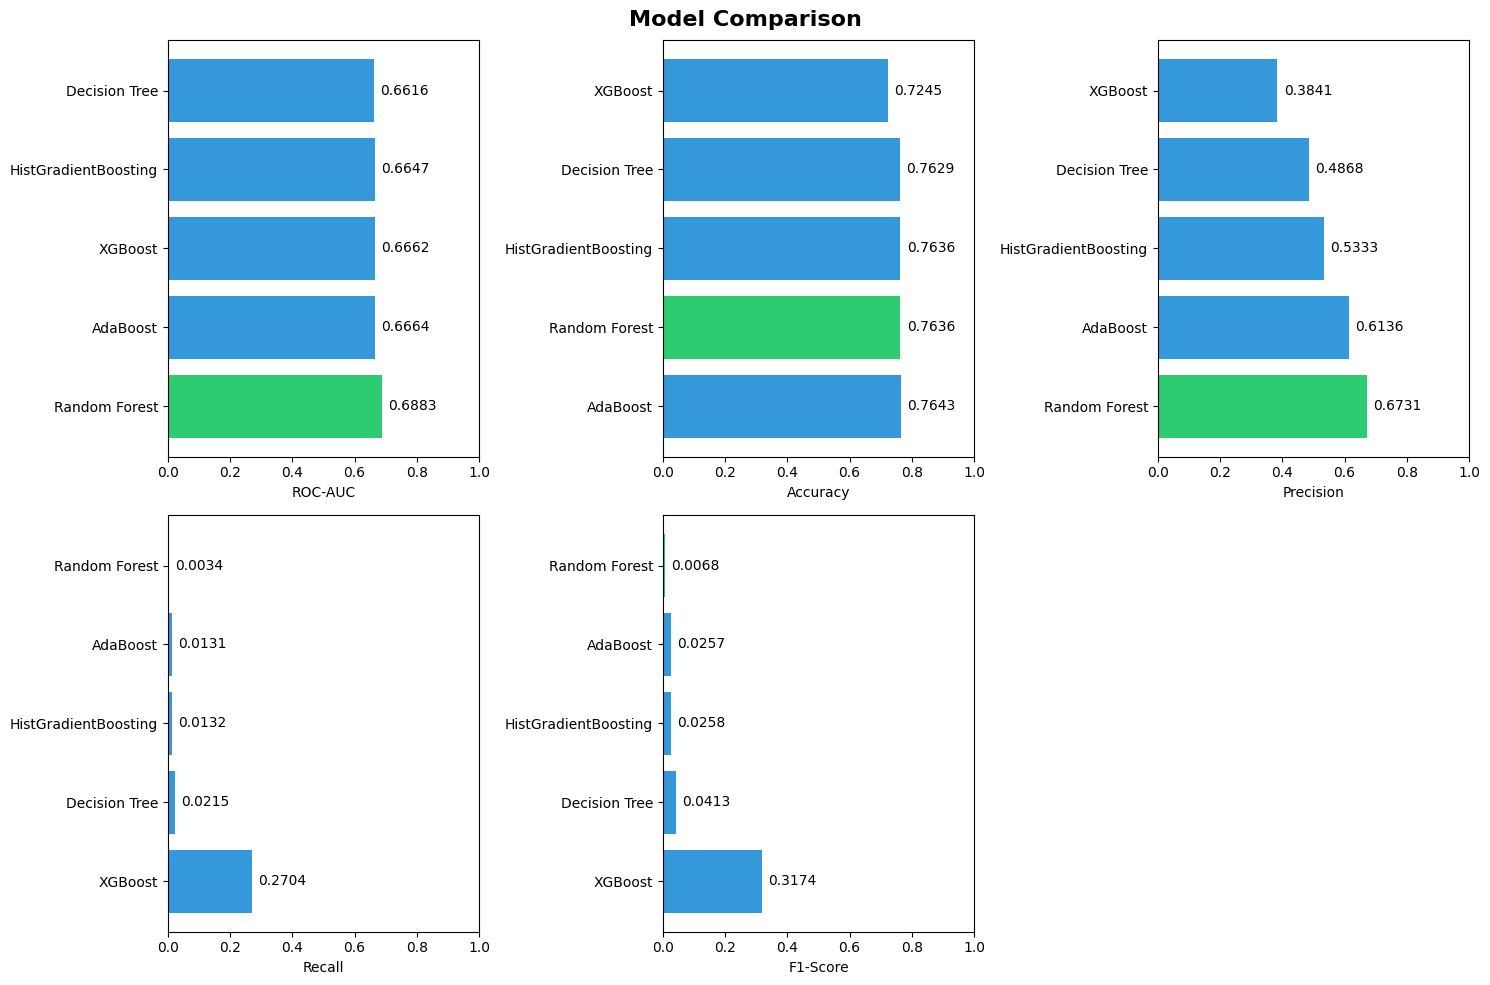

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Model Comparison", fontsize=16, fontweight="bold")

metrics = ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-Score"]
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    comparison_df_sorted = comparison_df.sort(metric, descending=True)
    colors = [
        "#2ecc71" if model == best_model_name else "#3498db"
        for model in comparison_df_sorted["Model"]
    ]
    ax.barh(comparison_df_sorted["Model"], comparison_df_sorted[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
    for i, v in enumerate(comparison_df_sorted[metric]):
        ax.text(v + 0.02, i, f"{v:.4f}", va="center")

# Remove the empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

if EXPORT:
    # Save the plot
    fig.savefig(
        Path("models/expanded/model_comparison.png"), dpi=300, bbox_inches="tight"
    )

# Save the trained models for later use

In [22]:
import json
from pickle import dump

if EXPORT:
    models_dir = Path("models/expanded")
    models_dir.mkdir(parents=True, exist_ok=True)

    with open(f"{models_dir}/model.pkl", "wb") as f:
        dump(calibrated_best_model, f, protocol=5)

    # Save best model metadata with all models' performance
    metadata = {
        "feature_columns": cols,
        "categorical_columns": categorical_cols,
        "categorical_mappings": category_mappings,
        "best_model": best_model_name,
        "best_model_params": search_results[best_model_name],
        "all_models_performance": comparison_df.to_dicts(),  # All model comparisons
        "all_models_best_params": search_results,  # Best params for each model
    }
    with open(models_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, default=str)

    print("Metadata saved to models/metadata.json")
    print(f"Best model for export: {best_model_name}")

Metadata saved to models/metadata.json
Best model for export: Random Forest
